In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
warnings.filterwarnings('ignore')

In [57]:
from scipy.stats import chi2_contingency
from scipy import stats


# ─── HÀM 1: T-TEST (X LIÊN TỤC VS Y ĐỊNH TÍNH NHỊ PHÂN) ─────────────────────
def filter_by_ttest(df, cont_col, binary_target_col):
    """Kiểm định mối quan hệ giữa Biến độc lập (Liên tục) và Biến phụ thuộc (Định tính 2 nhóm).

    Sử dụng Welch's T-test (equal_var=False) để đảm bảo an toàn phân phối.
    """
    # Làm sạch dữ liệu khuyết thiếu (NaN)
    valid_data = df[[cont_col, binary_target_col]].dropna()

    # Lấy nhãn của 2 nhóm trong biến phụ thuộc
    groups = valid_data[binary_target_col].unique()

    # Tách biến liên tục thành 2 mảng độc lập dựa trên nhãn định tính
    group1 = valid_data[valid_data[binary_target_col] == groups[0]][
        cont_col
    ].values
    group2 = valid_data[valid_data[binary_target_col] == groups[1]][
        cont_col
    ].values

    # Chạy kiểm định Welch's t-test
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    conclusion = (
        "CÓ ý nghĩa thống kê (Bác bỏ H₀)"
        if p_value < 0.05
        else "KHÔNG có ý nghĩa (Chấp nhận H₀)"
    )

    print(
        f"--- KIỂM ĐỊNH T-TEST: Độc lập [{cont_col}] vs Phụ thuộc [{binary_target_col}] ---"
    )
    print(f"  Chỉ số t-statistic : {t_stat:.4f}")
    print(f"  p-value            : {p_value:.4f}  →  {conclusion}\n")

    return p_value


# ─── HÀM 2: CHECK CHI-SQUARE (ĐA CỘNG TUYẾN GIỮA CÁC X PHÂN LOẠI) ───────────
def check_chi_square(df, col1, col2):
    """Kiểm định tính độc lập giữa 2 biến phân loại độc lập với nhau.

    Mục tiêu: Phát hiện hiện tượng Đa cộng tuyến phân loại .
    """
    # Lập bảng tần suất chéo (Contingency Table) giữa 2 đặc trưng
    contingency_table = pd.crosstab(df[col1], df[col2])

    # Chạy kiểm định Chi-Square độc lập
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    conclusion = (
        "CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến phụ thuộc nhau)"
        if p_value < 0.05
        else "AN TOÀN (Chấp nhận H₀ - Hai biến độc lập nhau)"
    )

    print(f"--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [{col1}] & [{col2}] ---")
    print(f"  Giá trị thống kê χ² : {chi2_stat:.4f}")
    print(f"  p-value            : {p_value:.4f}  →  {conclusion}\n")

    return p_value


# ─── HÀM 3: FILTER CHI-SQUARE + CRAMER'S V (X PHÂN LOẠI VS Y ĐỊNH TÍNH) ─────
def filter_by_chi_square(df, cat_col, target_col):
    """Kiểm định mối quan hệ giữa Biến độc lập (Phân loại) và Biến phụ thuộc (Định tính).

    Tính toán thêm hệ số Cramer's V để đo lường độ mạnh tương quan phân loại.
    """
    # Lập bảng tần suất chéo
    contingency_table = pd.crosstab(df[cat_col], df[target_col])

    # 1. Tính toán Chi-Square để lấy p-value
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    # 2. Tính toán Cramer's V (Kích thước hiệu ứng / Hệ số tương quan phân loại)
    n = contingency_table.sum().sum()  # Tổng số lượng mẫu dữ liệu sạch
    r, c = contingency_table.shape  # Số lượng hàng và số lượng cột của bảng chéo
    min_dim = min(r - 1, c - 1)  # Lấy giá trị nhỏ nhất giữa (Hàng-1) và (Cột-1)

    # Công thức toán gốc của Cramer's V
    cramer_v = (
        np.sqrt(chi2_stat / (n * min_dim)) if min_dim > 0 and n > 0 else 0
    )

    conclusion = (
        "CÓ ý nghĩa thống kê (Bác bỏ H₀)"
        if p_value < 0.05
        else "KHÔNG có ý nghĩa (Chấp nhận H₀)"
    )

    # Gợi ý đánh giá sức mạnh mối quan hệ theo tiêu chuẩn Cramer's V
    if cramer_v < 0.1:
        strength = "Rất yếu (Nên loại bỏ)"
    elif cramer_v < 0.3:
        strength = "Trung bình"
    else:
        strength = "Mạnh (Ưu tiên giữ lại để train)"

    print(
        f"--- KIỂM ĐỊNH FEATURE: Đặc trưng [{cat_col}] tác động lên Target [{target_col}] ---"
    )
    print(f"  p-value (Chi-Square) : {p_value:.4f}  →  {conclusion}")
    print(f"  Hệ số Cramer's V     : {cramer_v:.4f}  →  Sức mạnh: {strength}\n")

    return p_value, cramer_v

def compute_vif(df, features):
    """Tính VIF chính xác cho từng biến liên tục ."""
    # 1. Trích xuất các biến liên tục và xóa dòng trống
    X = df[features].dropna()
    
    # 2. BẮT BUỘC: Thêm cột hằng số const = 1 để làm điểm tựa cho thuật toán
    X_with_const = sm.add_constant(X)
    
    # 3. Tính toán VIF cho từng đặc trưng (bỏ qua cột const ở chỉ số đầu tiên)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    vif_data["VIF"] = [
        variance_inflation_factor(X_with_const.values, i + 1) # i + 1 để bỏ qua cột const nằm ở vị trí index 0
        for i in range(len(features))
    ]
    
    # 4. Sắp xếp kết quả giảm dần để dễ quan sát
    vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
    return vif_data.round(4)


# Phân tích khả năng khách hàng rời bỏ (Customer Churn)
## Mô hình: Hồi quy Logistic (Logistic Regression)

In [58]:
import json
with open('Customer_Churn_02.json', 'r') as f:
    data = json.load(f)
df = pd.DataFrame(data)

In [59]:
df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [61]:
print("--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---")
nan_ratio = df.isnull().mean()
print(nan_ratio)
print("-" * 50)

--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---
RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64
--------------------------------------------------


In [62]:
# Loại bỏ các cột định danh không có ý nghĩa phân tích
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [63]:
print("--- Số giá trị duy nhất của các biến phân loại ---")
print(f"Geography     : {df['Geography'].value_counts().count()} nhóm")
print(f"Gender        : {df['Gender'].value_counts().count()} nhóm")
print(f"HasCrCard     : {df['HasCrCard'].value_counts().count()} nhóm")
print(f"IsActiveMember: {df['IsActiveMember'].value_counts().count()} nhóm")
print(f"NumOfProducts : {df['NumOfProducts'].value_counts().count()} nhóm")


--- Số giá trị duy nhất của các biến phân loại ---
Geography     : 3 nhóm
Gender        : 2 nhóm
HasCrCard     : 2 nhóm
IsActiveMember: 2 nhóm
NumOfProducts : 4 nhóm


## Phân tích biến liên tục

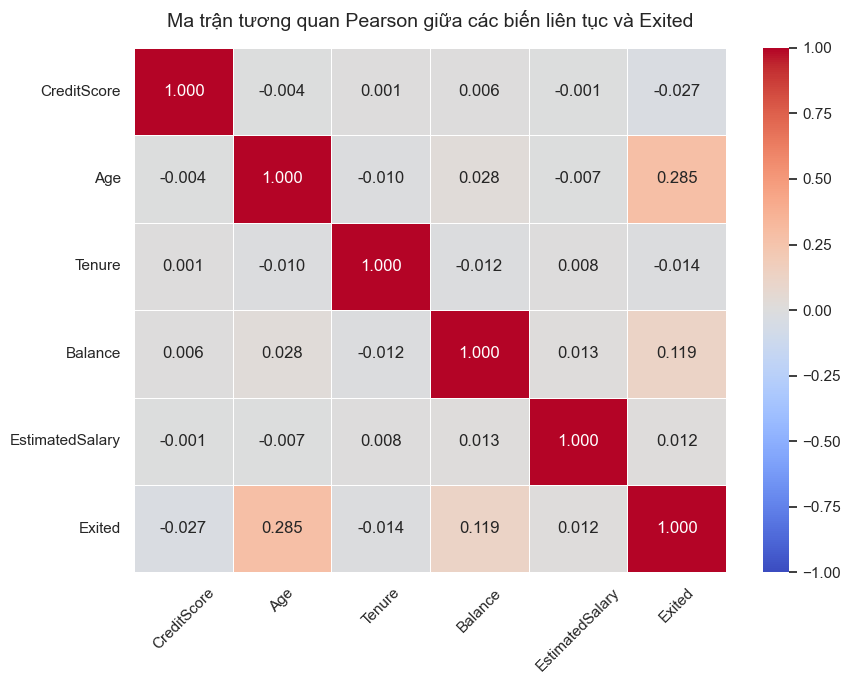

In [64]:
# 1. Xác định danh sách các biến liên tục và biến mục tiêu
continuous_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
target = 'Exited'

# Gom tất cả vào một danh sách chung để tính ma trận tương quan
cols_to_corr = continuous_features + [target]

# 2. Tính toán ma trận tương quan Pearson từ DataFrame
corr_matrix = df[cols_to_corr].corr()

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma trận tương quan Pearson giữa các biến liên tục và Exited', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

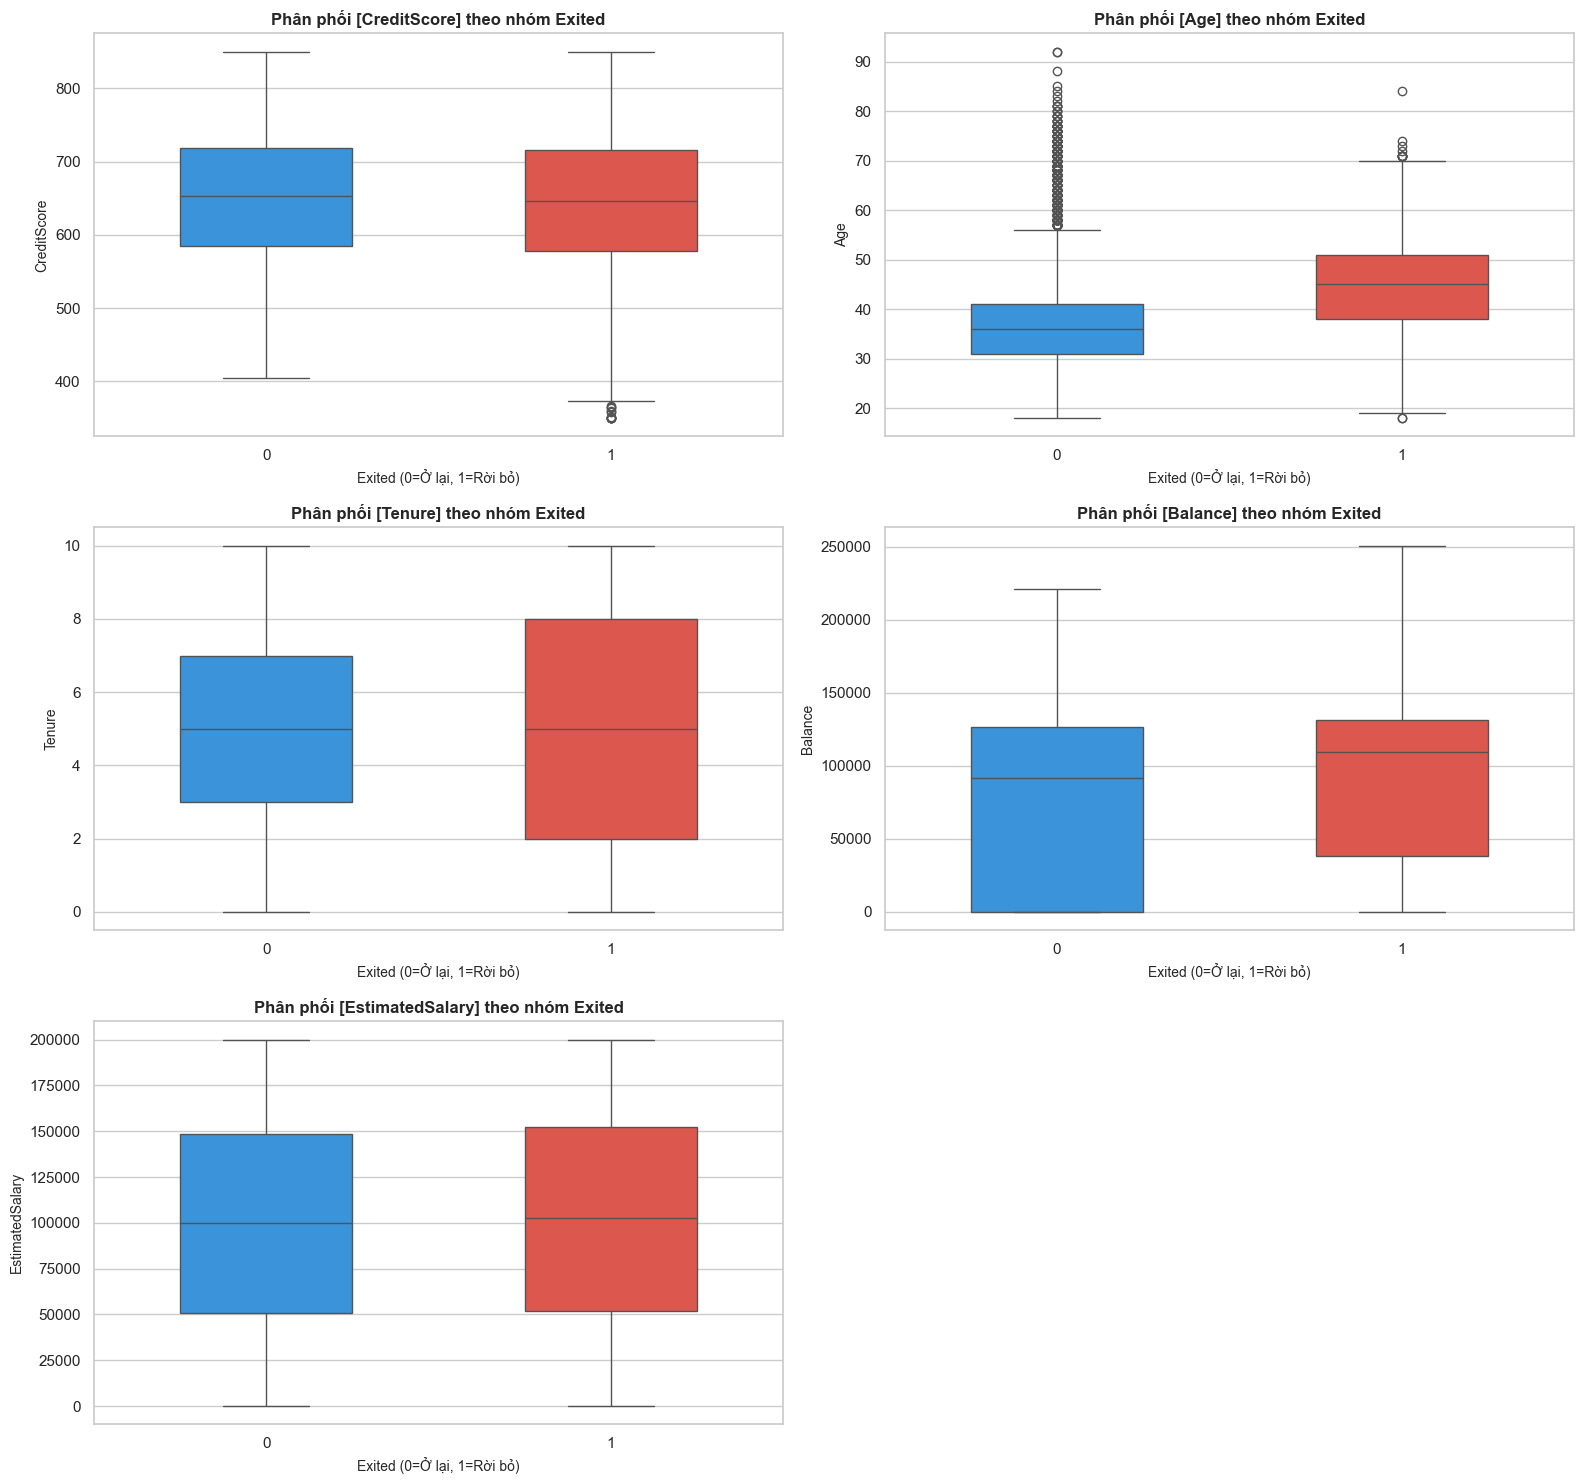

In [65]:


# 2. Thiết lập cấu hình thẩm mỹ cho đồ thị
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 15))
axes = axes.flatten()

# 3. Vòng lặp vẽ Boxplot cho từng biến liên tục theo nhóm Exited
for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df,
        x=target,
        y=feature,
        ax=axes[i],
        palette=['#2196F3', '#F44336'],
        width=0.5
    )
    axes[i].set_title(f'Phân phối [{feature}] theo nhóm {target}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Exited (0=Ở lại, 1=Rời bỏ)', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=10)

# Ẩn subplot thừa
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [66]:
vif_df = compute_vif(df, continuous_features)
print(vif_df.to_string(index=False))
print()

        Feature    VIF
        Balance 1.0012
            Age 1.0010
         Tenure 1.0003
EstimatedSalary 1.0003
    CreditScore 1.0001



In [67]:
for col in continuous_features:
    filter_by_ttest(df, cont_col=col, binary_target_col='Exited')

--- KIỂM ĐỊNH T-TEST: Độc lập [CreditScore] vs Phụ thuộc [Exited] ---
  Chỉ số t-statistic : -2.6347
  p-value            : 0.0085  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)

--- KIỂM ĐỊNH T-TEST: Độc lập [Age] vs Phụ thuộc [Exited] ---
  Chỉ số t-statistic : 30.4192
  p-value            : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)

--- KIỂM ĐỊNH T-TEST: Độc lập [Tenure] vs Phụ thuộc [Exited] ---
  Chỉ số t-statistic : -1.3843
  p-value            : 0.1664  →  KHÔNG có ý nghĩa (Chấp nhận H₀)

--- KIỂM ĐỊNH T-TEST: Độc lập [Balance] vs Phụ thuộc [Exited] ---
  Chỉ số t-statistic : 12.4713
  p-value            : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)

--- KIỂM ĐỊNH T-TEST: Độc lập [EstimatedSalary] vs Phụ thuộc [Exited] ---
  Chỉ số t-statistic : 1.2034
  p-value            : 0.2289  →  KHÔNG có ý nghĩa (Chấp nhận H₀)



## Ho : Biến độc lập không có ý nghĩa với biến mục tiêu 
- Nhìn tổng quan thì có thể thấy các biến độc lập tương quan khá thấp với biến mục tiêu, nhưng vẫn sẽ giữ lại các biến có ý nghĩa thống kê
- CreditScore, Age, Balance có p-value < 0.05 => Bác bỏ Ho  

## Phân tích biến phân loại

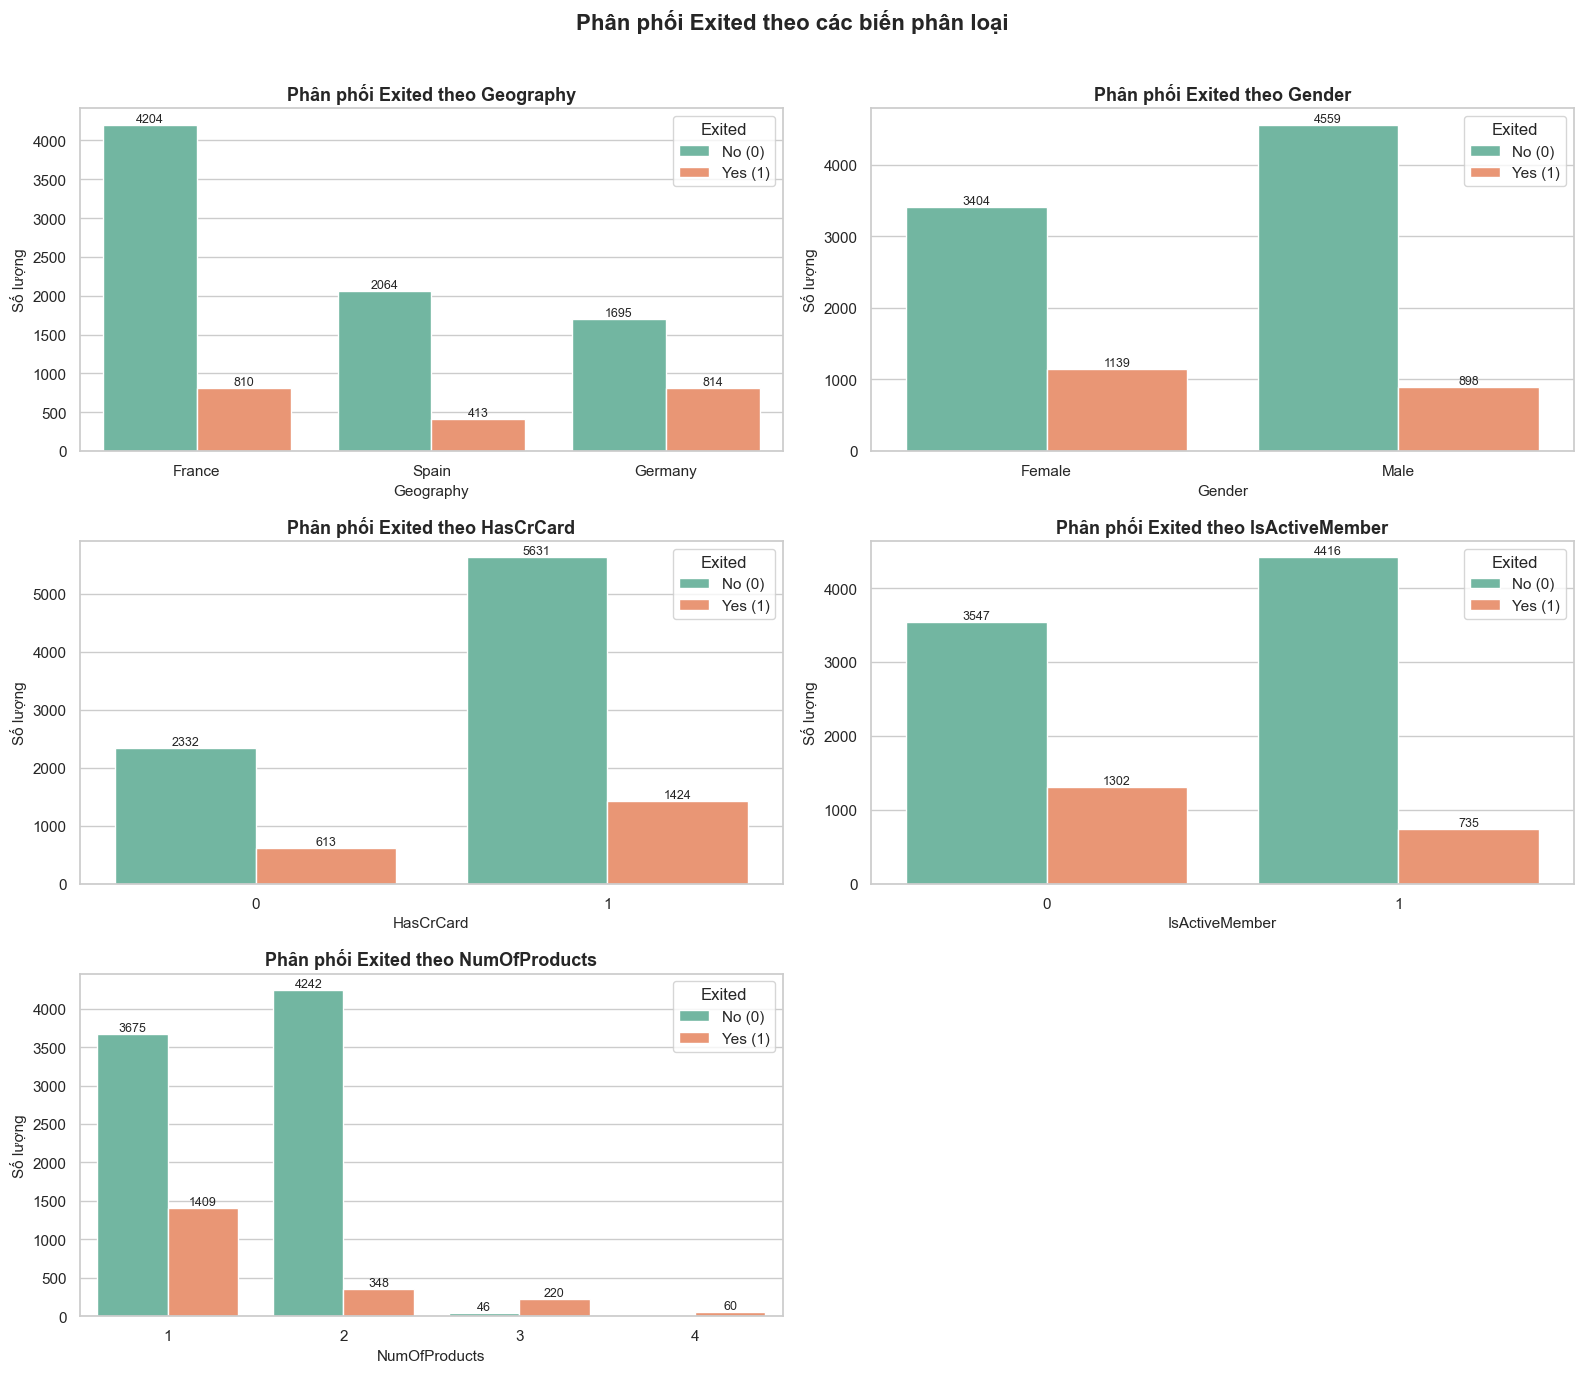

In [68]:
# Danh sách biến phân loại
cat_cols = ['Geography', 'Gender', 'HasCrCard',
            'IsActiveMember', 'NumOfProducts']

target = 'Exited'

# Style
sns.set_theme(style="whitegrid")

# Tạo subplot
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

# Vẽ Countplot
for i, col in enumerate(cat_cols):

    sns.countplot(
        data=df,
        x=col,
        hue=target,          # phân màu theo Exited
        ax=axes[i],
        palette='Set2'
    )

    axes[i].set_title(
        f'Phân phối {target} theo {col}',
        fontsize=13,
        fontweight='bold'
    )

    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Số lượng', fontsize=11)

    # Legend rõ ràng hơn
    axes[i].legend(
        title='Exited',
        labels=['No (0)', 'Yes (1)']
    )

    # Hiển thị số trên cột
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt='%d',
            fontsize=9
        )

# Xóa subplot dư
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Phân phối Exited theo các biến phân loại',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [69]:
import itertools
target = "Exited"


print("=" * 70)
print("SÀNG LỌC ĐẶC TRƯNG MẠNH (X PHÂN LOẠI VS TARGET NHỊ PHÂN Y)")
print("=" * 70)

for col in cat_cols:
    filter_by_chi_square(df, cat_col=col, target_col=target)

SÀNG LỌC ĐẶC TRƯNG MẠNH (X PHÂN LOẠI VS TARGET NHỊ PHÂN Y)
--- KIỂM ĐỊNH FEATURE: Đặc trưng [Geography] tác động lên Target [Exited] ---
  p-value (Chi-Square) : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)
  Hệ số Cramer's V     : 0.1736  →  Sức mạnh: Trung bình

--- KIỂM ĐỊNH FEATURE: Đặc trưng [Gender] tác động lên Target [Exited] ---
  p-value (Chi-Square) : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)
  Hệ số Cramer's V     : 0.1063  →  Sức mạnh: Trung bình

--- KIỂM ĐỊNH FEATURE: Đặc trưng [HasCrCard] tác động lên Target [Exited] ---
  p-value (Chi-Square) : 0.4924  →  KHÔNG có ý nghĩa (Chấp nhận H₀)
  Hệ số Cramer's V     : 0.0069  →  Sức mạnh: Rất yếu (Nên loại bỏ)

--- KIỂM ĐỊNH FEATURE: Đặc trưng [IsActiveMember] tác động lên Target [Exited] ---
  p-value (Chi-Square) : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)
  Hệ số Cramer's V     : 0.1559  →  Sức mạnh: Trung bình

--- KIỂM ĐỊNH FEATURE: Đặc trưng [NumOfProducts] tác động lên Target [Exited] ---
  p-value (Chi-Square) : 0.000

### Ho: Biến độc lập không liên quan đến biến mục tiêu
- Geography, Gender, IsActiveMember, NumOfProducts có p-value <0.05 => Bác bỏ Ho 
### Xét hệ số cramerV đo mức độ tương quan.
- NumOfProducts ưu tiên

## Kiểm tra đa cộng tuyến giữa các biến phân loại (Chi-Square)

In [70]:

print("=" * 70)
print("KIỂM TRA ĐA CỘNG TUYẾN PHÂN LOẠI (X PHÂN LOẠI VS X PHÂN LOẠI)")
print("=" * 70)
cat_cols_filtered = ['Geography','Gender', 'IsActiveMember', 'NumOfProducts']
# itertools.combinations giúp tự động bắt cặp độc nhất giữa các biến trong danh sách
for col1, col2 in itertools.combinations(cat_cols_filtered, 2):
    check_chi_square(df, col1, col2)

KIỂM TRA ĐA CỘNG TUYẾN PHÂN LOẠI (X PHÂN LOẠI VS X PHÂN LOẠI)
--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [Geography] & [Gender] ---
  Giá trị thống kê χ² : 6.9182
  p-value            : 0.0315  →  CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến phụ thuộc nhau)

--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [Geography] & [IsActiveMember] ---
  Giá trị thống kê χ² : 5.3047
  p-value            : 0.0705  →  AN TOÀN (Chấp nhận H₀ - Hai biến độc lập nhau)

--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [Geography] & [NumOfProducts] ---
  Giá trị thống kê χ² : 49.2422
  p-value            : 0.0000  →  CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến phụ thuộc nhau)

--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [Gender] & [IsActiveMember] ---
  Giá trị thống kê χ² : 4.9923
  p-value            : 0.0255  →  CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến phụ thuộc nhau)

--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [Gender] & [NumOfProducts] ---
  Giá trị thống kê χ² : 20.4871
  p-value            : 0.0001  →  CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến ph

### Ho: Hai biến không liên quan nhau


- => Bỏ gender 
  

In [71]:
cat_cols_filtered_2 = ['Geography', 'IsActiveMember', 'NumOfProducts']

print("=" * 60)
print("KIỂM ĐỊNH CHI-SQUARE: Đa cộng tuyến giữa biến phân loại")
print("=" * 60)
for col1, col2 in itertools.combinations(cat_cols_filtered_2, 2):
    check_chi_square(df, col1, col2)

KIỂM ĐỊNH CHI-SQUARE: Đa cộng tuyến giữa biến phân loại
--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [Geography] & [IsActiveMember] ---
  Giá trị thống kê χ² : 5.3047
  p-value            : 0.0705  →  AN TOÀN (Chấp nhận H₀ - Hai biến độc lập nhau)

--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [Geography] & [NumOfProducts] ---
  Giá trị thống kê χ² : 49.2422
  p-value            : 0.0000  →  CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến phụ thuộc nhau)

--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [IsActiveMember] & [NumOfProducts] ---
  Giá trị thống kê χ² : 17.1941
  p-value            : 0.0006  →  CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến phụ thuộc nhau)



- [Geography]      & [NumOfProducts]        => Bác bỏ Ho 

- [IsActiveMember] & [NumOfProducts]        => Bác bỏ Ho  

- =>  sẽ bỏ Geography, IsActiveMember vì  NumOfProducts ưu tiên có  Hệ số Cramer's V cáo nhất

## Huấn luyện mô hình Logistic Regression

In [72]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# =====================================================================
# BƯỚC 1: CHỌN BIẾN VÀ MÃ HÓA
# =====================================================================
# Giữ lại các biến có ý nghĩa thống kê từ phân tích trên
df_model = df[[ 'Age', 'Balance',
               'NumOfProducts', 'CreditScore',
                'Exited']].copy()

# One-hot encoding cho biến phân loại (drop_first=True: quy tắc k-1)
df_encoded = pd.get_dummies(df_model,
                            columns=['NumOfProducts'],
                            drop_first=True, dtype=int)

print("Các cột sau khi mã hóa:")
print(df_encoded.columns.tolist())
print(f"\nKích thước dữ liệu: {df_encoded.shape}")

Các cột sau khi mã hóa:
['Age', 'Balance', 'CreditScore', 'Exited', 'NumOfProducts_2', 'NumOfProducts_3', 'NumOfProducts_4']

Kích thước dữ liệu: (10000, 7)


In [73]:
# =====================================================================
# BƯỚC 2: TÁCH BIẾN VÀ CHUẨN HÓA DỮ LIỆU
# =====================================================================
X = df_encoded.drop(columns=['Exited'])
y = df_encoded['Exited']

# Chuẩn hóa để Logistic Regression hội tụ tốt hơn
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Kích thước X: {X_scaled.shape}")
print(f"Phân phối y:\n{y.value_counts()}")

Kích thước X: (10000, 6)
Phân phối y:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [74]:
# =====================================================================
# BƯỚC 3: STRATIFIED K-FOLD CROSS VALIDATION
# =====================================================================
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

acc_scores, prec_scores, rec_scores, f1_scores, auc_scores = [], [], [], [], []

print(f"--- BẮT ĐẦU CHẠY LOGISTIC REGRESSION VỚI {n_splits}-FOLD CROSS VALIDATION ---\n")
print(f"{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<10} {'F1':<10} {'AUC-ROC'}")
print("-" * 65)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Huấn luyện Logistic Regression
    log_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
    log_model.fit(X_train, y_train)

    y_pred = log_model.predict(X_test)
    y_prob = log_model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)

    print(f"{fold:<6} {acc:<12.4f} {prec:<12.4f} {rec:<10.4f} {f1:<10.4f} {auc:.4f}")

print("-" * 65)
print("\n" + "="*55)
print("KẾT LUẬN HIỆU SUẤT TRUNG BÌNH QUA CÁC FOLDS:")
print(f"  Accuracy  trung bình : {np.mean(acc_scores):.4f} (+/- {np.std(acc_scores):.4f})")
print(f"  Precision trung bình : {np.mean(prec_scores):.4f} (+/- {np.std(prec_scores):.4f})")
print(f"  Recall    trung bình : {np.mean(rec_scores):.4f} (+/- {np.std(rec_scores):.4f})")
print(f"  F1-Score  trung bình : {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"  AUC-ROC   trung bình : {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")
print("="*55)

--- BẮT ĐẦU CHẠY LOGISTIC REGRESSION VỚI 5-FOLD CROSS VALIDATION ---

Fold   Accuracy     Precision    Recall     F1         AUC-ROC
-----------------------------------------------------------------
1      0.8120       0.6096       0.2181     0.3213     0.8027
2      0.8040       0.5482       0.2230     0.3171     0.7855
3      0.8115       0.6014       0.2187     0.3207     0.8214
4      0.8160       0.6327       0.2285     0.3357     0.8022
5      0.8135       0.6328       0.1990     0.3028     0.8121
-----------------------------------------------------------------

KẾT LUẬN HIỆU SUẤT TRUNG BÌNH QUA CÁC FOLDS:
  Accuracy  trung bình : 0.8114 (+/- 0.0040)
  Precision trung bình : 0.6049 (+/- 0.0310)
  Recall    trung bình : 0.2175 (+/- 0.0100)
  F1-Score  trung bình : 0.3195 (+/- 0.0105)
  AUC-ROC   trung bình : 0.8048 (+/- 0.0119)


In [75]:
# =====================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH CUỐI CÙNG TRÊN TOÀN BỘ DỮ LIỆU
# =====================================================================
final_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
final_model.fit(X_scaled, y)

print("Mô hình cuối đã được huấn luyện trên toàn bộ dữ liệu.")
print(f"Số lượng đặc trưng: {X_scaled.shape[1]}")

Mô hình cuối đã được huấn luyện trên toàn bộ dữ liệu.
Số lượng đặc trưng: 6


In [76]:
# =====================================================================
# BẢNG HỆ SỐ HỒI QUY LOGISTIC (statsmodels để có p-value)
# =====================================================================
X_const = sm.add_constant(X_scaled)
logit_model = sm.Logit(y, X_const)
logit_result = logit_model.fit(method='bfgs', maxiter=300, disp=False)

print("=" * 80)
print("TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY LOGISTIC (statsmodels):")
print(logit_result.summary())
print("=" * 80)

TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY LOGISTIC (statsmodels):
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9993
Method:                           MLE   Df Model:                            6
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                  0.2020
Time:                        17:57:49   Log-Likelihood:                -4034.0
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.6337      1.085     -1.506      0.132      -3.760       0.493
Age                 0.6506      0.027     24.412      0.000 

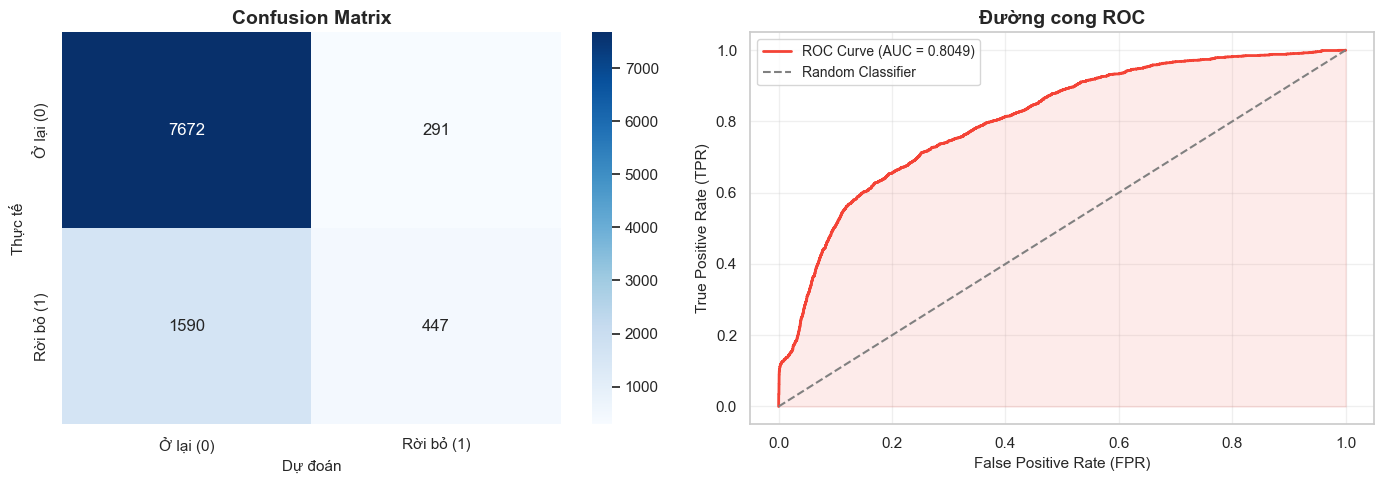


--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

   Ở lại (0)       0.83      0.96      0.89      7963
  Rời bỏ (1)       0.61      0.22      0.32      2037

    accuracy                           0.81     10000
   macro avg       0.72      0.59      0.61     10000
weighted avg       0.78      0.81      0.77     10000



In [77]:
# =====================================================================
# CONFUSION MATRIX VÀ CLASSIFICATION REPORT (trên toàn bộ dữ liệu)
# =====================================================================
y_pred_final = final_model.predict(X_scaled)
y_prob_final = final_model.predict_proba(X_scaled)[:, 1]

cm = confusion_matrix(y, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ở lại (0)', 'Rời bỏ (1)'],
            yticklabels=['Ở lại (0)', 'Rời bỏ (1)'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dự đoán', fontsize=11)
axes[0].set_ylabel('Thực tế', fontsize=11)

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y, y_prob_final)
auc_val = roc_auc_score(y, y_prob_final)
axes[1].plot(fpr, tpr, color='#F44336', lw=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#F44336')
axes[1].set_title('Đường cong ROC', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y, y_pred_final, target_names=['Ở lại (0)', 'Rời bỏ (1)']))

In [78]:
# ==========================================================
# DỰ ĐOÁN CHO KHÁCH HÀNG MỚI
# ==========================================================

# 1. Khách hàng mới
new_customer = pd.DataFrame({
    'CreditScore': [650],
    'Age': [40],
    'Balance': [80000.0],
    'NumOfProducts': [2]
})

# 2. One-hot encoding giống train
new_customer_encoded = pd.get_dummies(
    new_customer,
    columns=['NumOfProducts'],
    drop_first=True,
    dtype=int
)

# 3. Đảm bảo đủ cột giống train
new_customer_encoded = new_customer_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

# 4. Chuẩn hóa
new_customer_scaled = pd.DataFrame(
    scaler.transform(new_customer_encoded),
    columns=X.columns
)

# 5. Dự đoán
pred_class = final_model.predict(new_customer_scaled)[0]
pred_prob  = final_model.predict_proba(new_customer_scaled)[0][1]

print("\n--- KẾT QUẢ DỰ ĐOÁN KHÁCH HÀNG MỚI ---")
print(f"Xác suất rời bỏ   : {pred_prob*100:.2f}%")
print(f"Dự đoán phân loại : {'RỜI BỎ (Exited=1)' if pred_class == 1 else 'Ở LẠI (Exited=0)'}")


--- KẾT QUẢ DỰ ĐOÁN KHÁCH HÀNG MỚI ---
Xác suất rời bỏ   : 25.81%
Dự đoán phân loại : Ở LẠI (Exited=0)
